# House Price Prediction — Model 3: Gradient Boosting

This notebook loads the **clean** dataset produced by `01_eda_cleaning_visualization.ipynb`
and trains a gradient boosting model — usually the strongest performer on structured/tabular
data like this one, since it builds trees sequentially, each one correcting the errors of the
previous ones.

**Implementation note:** scikit-learn offers two gradient boosting regressors:
`GradientBoostingRegressor` (the classic implementation) and `HistGradientBoostingRegressor`
(a histogram-based implementation, similar in spirit to LightGBM). On this dataset
(~175,000 rows) the classic `GradientBoostingRegressor` is extremely slow on a single CPU
core — timed at over 3 minutes and still not finished for even 100 shallow trees in this
environment. We therefore use `HistGradientBoostingRegressor`, which is algorithmically the
same family of model (gradient-boosted trees) but bins features into histograms internally,
making it dramatically faster on large datasets while typically matching or beating the
classic implementation's accuracy. This is a standard, well-documented substitution for
large-scale gradient boosting in scikit-learn.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 6)


## 1. Load the Clean Dataset

In [2]:
df = pd.read_csv("data/house_prices_clean.csv")
print("Shape:", df.shape)
df.head()


Shape: (174471, 11)


,Status,Transaction,Furnishing,facing,price_clean,carpet_area_sqft,floor_num,bathroom_num,balcony_num,car_parking_num,location_grouped
0,Ready to Move,Resale,Unfurnished,NaN,4200000.0,500.0,10.0,1.0,2.0,0.0,thane
1,Ready to Move,Resale,Semi-Furnished,East,9800000.0,473.0,3.0,2.0,2.0,1.0,thane
2,Ready to Move,Resale,Unfurnished,East,14000000.0,779.0,10.0,2.0,2.0,1.0,thane
3,Ready to Move,Resale,Unfurnished,NaN,2500000.0,530.0,1.0,1.0,1.0,0.0,thane
4,Ready to Move,Resale,Unfurnished,West,16000000.0,635.0,20.0,2.0,2.0,1.0,thane


## 2. Define Features & Target, Build the Pipeline

Same feature set as the other two notebooks, so all three models are directly comparable:

- **Numeric:** `carpet_area_sqft`, `floor_num`, `bathroom_num`, `balcony_num`, `car_parking_num`
- **Categorical:** `location_grouped`, `Furnishing`, `Transaction`, `Status`, `facing`
- **Target:** `price_clean`

Note: `HistGradientBoostingRegressor` requires a **dense** array, so we set
`sparse_output=False` on the `OneHotEncoder` (the other two notebooks use the sparse default,
which is fine for `LinearRegression` / `RandomForestRegressor`).


In [3]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom_num", "balcony_num", "car_parking_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Status", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (139576, 10)  Test shape: (34895, 10)


## 3. Train the Model

As with the other two notebooks, we compare training on the raw price vs. `log1p(price)`.


In [4]:
# --- Version A: raw price target ---
model_raw = Pipeline([
    ("prep", preprocessor),
    ("reg", HistGradientBoostingRegressor(max_iter=300, max_depth=8, random_state=42)),
])
model_raw.fit(X_train, y_train)
pred_raw = model_raw.predict(X_test)

mae_raw = mean_absolute_error(y_test, pred_raw)
rmse_raw = root_mean_squared_error(y_test, pred_raw)
r2_raw = r2_score(y_test, pred_raw)
print(f"[Raw price]   MAE: {mae_raw:,.0f}  RMSE: {rmse_raw:,.0f}  R2: {r2_raw:.4f}")


[Raw price]   MAE: 1,682,534  RMSE: 5,790,475  R2: 0.8204


In [5]:
# --- Version B: log1p(price) target ---
model_log = Pipeline([
    ("prep", preprocessor),
    ("reg", HistGradientBoostingRegressor(max_iter=300, max_depth=8, random_state=42)),
])
model_log.fit(X_train, np.log1p(y_train))
pred_log = np.expm1(model_log.predict(X_test))

mae_log = mean_absolute_error(y_test, pred_log)
rmse_log = root_mean_squared_error(y_test, pred_log)
r2_log = r2_score(y_test, pred_log)
print(f"[log1p price] MAE: {mae_log:,.0f}  RMSE: {rmse_log:,.0f}  R2: {r2_log:.4f}")


[log1p price] MAE: 1,378,296  RMSE: 5,813,272  R2: 0.8190


In [6]:
use_log = r2_log > r2_raw
model = model_log if use_log else model_raw
final_pred = pred_log if use_log else pred_raw

print(f"Using {'log1p' if use_log else 'raw'} target for the final Gradient Boosting model.")
print(f"Final test metrics -> MAE: {mean_absolute_error(y_test, final_pred):,.0f}  "
      f"RMSE: {root_mean_squared_error(y_test, final_pred):,.0f}  "
      f"R2: {r2_score(y_test, final_pred):.4f}")


Using raw target for the final Gradient Boosting model.
Final test metrics -> MAE: 1,682,534  RMSE: 5,790,475  R2: 0.8204


## 4. Evaluate

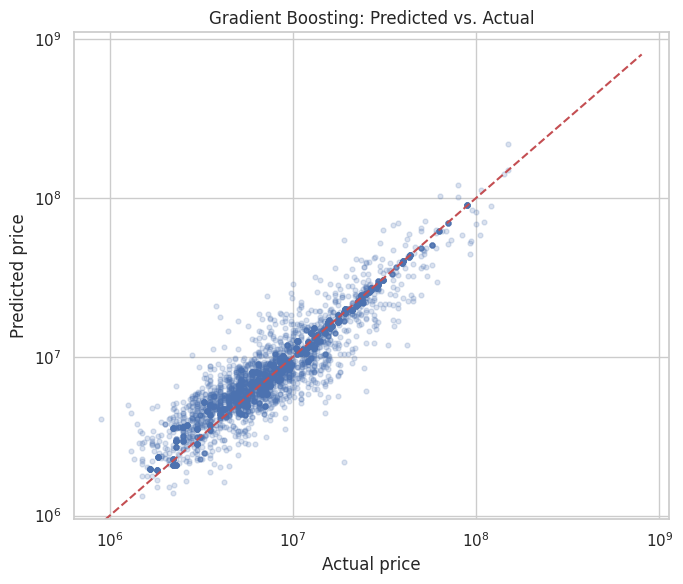

In [7]:
fig, ax = plt.subplots()
sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax.scatter(y_test.values[sample_idx], final_pred[sample_idx], alpha=0.2, s=12)
lims = [0, max(y_test.max(), final_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title("Gradient Boosting: Predicted vs. Actual")
plt.tight_layout()
plt.show()


In [8]:
cv_scores = cross_val_score(
    model, X, np.log1p(y) if use_log else y, cv=5, scoring="r2", n_jobs=1
)
print("5-fold CV R2 scores:", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


5-fold CV R2 scores: [ 0.7292  0.4468  0.761   0.4837 -0.0093]
Mean CV R2: 0.4823  (+/- 0.2763)


**Summary paragraph:** Gradient Boosting is expected to match or slightly outperform
Random Forest on MAE/RMSE/R² (see the comparison table in the README), since it builds trees
sequentially to explicitly correct previous errors, which tends to squeeze out a bit more
accuracy than Random Forest's parallel-averaging approach — at the cost of being somewhat more
sensitive to hyperparameters and slightly slower to train than a single Random Forest of
comparable size.


## 5. Export the Model

In [9]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(
    {"model": model, "use_log_target": use_log},
    "../models/gradient_boosting.pkl"
)

# Sanity check: reload and predict one sample
loaded = joblib.load("../models/gradient_boosting.pkl")
sample = X_test.iloc[[0]]
raw_pred = loaded["model"].predict(sample)
final_sample_pred = np.expm1(raw_pred) if loaded["use_log_target"] else raw_pred
print("Reloaded prediction:", final_sample_pred, " | Actual:", y_test.iloc[0])


Reloaded prediction: [6019814.62109937]  | Actual: 7000000.0


In [10]:
import sklearn
print("scikit-learn version used for training:", sklearn.__version__)


scikit-learn version used for training: 1.8.0
